In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
import io
import os

os.makedirs('styles', exist_ok=True)

def load_img(path_or_bytes, max_dim=512):
    if isinstance(path_or_bytes, bytes):
        img = Image.open(io.BytesIO(path_or_bytes)).convert('RGB')
    else:
        img = Image.open(path_or_bytes).convert('RGB')
    scale = max_dim / max(img.size)
    new_size = (int(img.size[0]*scale), int(img.size[1]*scale))
    img = img.resize(new_size, Image.LANCZOS)
    img = np.array(img, dtype=np.float32) / 255.0
    return tf.constant(img[np.newaxis, :])

def tensor_to_image(tensor):
    tensor = tensor * 255
    tensor = np.array(tensor, dtype=np.uint8)
    return Image.fromarray(tensor[0])

def gram_matrix(x):
    result = tf.linalg.einsum('bijc,bijd->bcd', x, x)
    return result / tf.cast(x.shape[1]*x.shape[2], tf.float32)

vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

style_layers = ['block1_conv1','block2_conv1','block3_conv1','block4_conv1','block5_conv1']
content_layers = ['block5_conv2']

style_extractor = tf.keras.Model([vgg.input], [vgg.get_layer(n).output for n in style_layers])
content_extractor = tf.keras.Model([vgg.input], [vgg.get_layer(n).output for n in content_layers])

def get_style(img):
    img = tf.keras.applications.vgg19.preprocess_input(img * 255)
    return [gram_matrix(o) for o in style_extractor(img)]

def get_content(img):
    img = tf.keras.applications.vgg19.preprocess_input(img * 255)
    return content_extractor(img)

def style_transfer(content_path, style_path, steps=1000, style_weight=1e-1, content_weight=1e4):
    content_img = load_img(content_path)
    style_img = load_img(style_path)

    target_style = get_style(style_img)
    target_content = get_content(content_img)

    generated = tf.Variable(content_img)
    opt = tf.optimizers.Adam(learning_rate=0.01)

    @tf.function
    def step():
        with tf.GradientTape() as tape:
            gen_style = get_style(generated)
            gen_content = get_content(generated)
            s_loss = tf.add_n([tf.reduce_mean((gs-ts)**2) for gs,ts in zip(gen_style, target_style)])
            c_loss = tf.reduce_mean((gen_content[0] - target_content[0])**2)
            loss = style_weight * s_loss + content_weight * c_loss
        grad = tape.gradient(loss, generated)
        opt.apply_gradients([(grad, generated)])
        generated.assign(tf.clip_by_value(generated, 0.0, 1.0))
        return loss

    for i in range(steps):
        loss = step()
        if i % 200 == 0:
            print(f"Step {i}/{steps} — Loss: {loss:.2f}")

    print("Done!")
    return tensor_to_image(generated)

print("✅ Setup complete!")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Setup complete!


In [ ]:
styles = {
    'van_gogh': 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg',
    'monet': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a4/Monet_-_Impression%2C_Sunrise.jpg/1280px-Monet_-_Impression%2C_Sunrise.jpg',
    'hokusai': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a5/Tsunami_by_hokusai_19th_century.jpg/1280px-Tsunami_by_hokusai_19th_century.jpg',
    'kandinsky': 'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b4/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg/1280px-Vassily_Kandinsky%2C_1913_-_Composition_7.jpg',
    'picasso': 'https://upload.wikimedia.org/wikipedia/en/4/4c/Les_Demoiselles_d%27Avignon.jpg',
}

headers = {'User-Agent': 'Mozilla/5.0'}
for name, url in styles.items():
    r = requests.get(url, headers=headers)
    with open(f'styles/{name}.jpg', 'wb') as f:
        f.write(r.content)
    print(f"✅ {name}")

print("\nAll styles downloaded!")

✅ van_gogh
✅ monet
✅ hokusai
✅ kandinsky
✅ picasso

All styles downloaded!


In [ ]:
for name in styles.keys():
    path = f'styles/{name}.jpg'
    try:
        img = Image.open(path)
        print(f"✅ {name}: {img.size}")
    except:
        print(f"❌ {name}: FAILED")

✅ van_gogh: (1280, 1014)
❌ monet: FAILED
✅ hokusai: (1280, 860)
❌ kandinsky: FAILED
❌ picasso: FAILED


In [ ]:
fixes = {
    'monet': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a4/Monet_-_Impression%2C_Sunrise.jpg/800px-Monet_-_Impression%2C_Sunrise.jpg',
    'kandinsky': 'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b4/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg/800px-Vassily_Kandinsky%2C_1913_-_Composition_7.jpg',
    'picasso': 'https://upload.wikimedia.org/wikipedia/en/thumb/4/4c/Les_Demoiselles_d%27Avignon.jpg/600px-Les_Demoiselles_d%27Avignon.jpg',
}

headers = {'User-Agent': 'Mozilla/5.0'}
for name, url in fixes.items():
    r = requests.get(url, headers=headers)
    with open(f'styles/{name}.jpg', 'wb') as f:
        f.write(r.content)
    try:
        img = Image.open(f'styles/{name}.jpg')
        print(f"✅ {name}: {img.size}")
    except:
        print(f"❌ {name}: still failed")

❌ monet: still failed
❌ kandinsky: still failed
✅ picasso: (600, 621)


In [ ]:
fixes2 = {
    'monet': 'https://upload.wikimedia.org/wikipedia/commons/thumb/5/54/Claude_Monet%2C_Impression%2C_soleil_levant%2C_1872.jpg/800px-Claude_Monet%2C_Impression%2C_soleil_levant%2C_1872.jpg',
    'kandinsky': 'https://upload.wikimedia.org/wikipedia/commons/thumb/9/9d/Vassily_Kandinsky%2C_1910_-_Untitled_%28First_Abstract_Watercolor%29.jpg/600px-Vassily_Kandinsky%2C_1910_-_Untitled_%28First_Abstract_Watercolor%29.jpg',
}

headers = {'User-Agent': 'Mozilla/5.0'}
for name, url in fixes2.items():
    r = requests.get(url, headers=headers)
    with open(f'styles/{name}.jpg', 'wb') as f:
        f.write(r.content)
    try:
        img = Image.open(f'styles/{name}.jpg')
        print(f"✅ {name}: {img.size}")
    except:
        print(f"❌ {name}: still failed")

❌ monet: still failed
❌ kandinsky: still failed


In [ ]:
import urllib.request

working_styles = {
    'munch': 'https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg/800px-Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg',
    'klimt': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/40/The_Kiss_-_Gustav_Klimt_-_Google_Cultural_Institute.jpg/800px-The_Kiss_-_Gustav_Klimt_-_Google_Cultural_Institute.jpg',
}

headers = {'User-Agent': 'Mozilla/5.0'}
for name, url in working_styles.items():
    r = requests.get(url, headers=headers)
    with open(f'styles/{name}.jpg', 'wb') as f:
        f.write(r.content)
    try:
        img = Image.open(f'styles/{name}.jpg')
        print(f"✅ {name}: {img.size}")
    except:
        print(f"❌ {name}: failed")

❌ munch: failed
❌ klimt: failed


Step 0/1000 — Loss: 17975040000.00
Step 200/1000 — Loss: 151097600.00
Step 400/1000 — Loss: 92925008.00
Step 600/1000 — Loss: 72044608.00
Step 800/1000 — Loss: 60942984.00
Done!


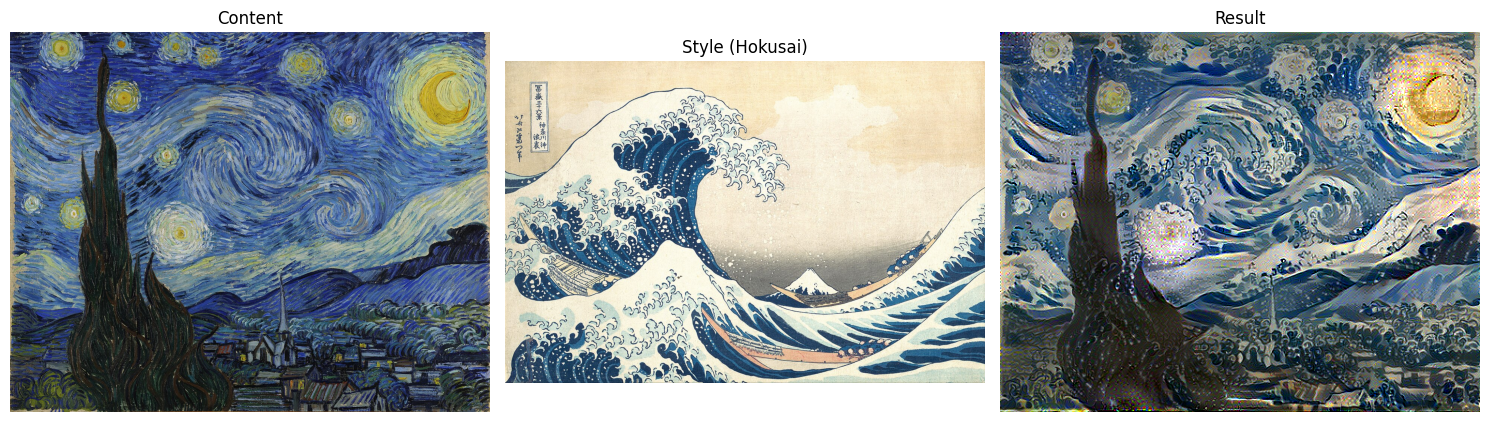

In [ ]:
result = style_transfer('styles/van_gogh.jpg', 'styles/hokusai.jpg', steps=1000)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(Image.open('styles/van_gogh.jpg'))
axes[0].set_title('Content')
axes[0].axis('off')
axes[1].imshow(Image.open('styles/hokusai.jpg'))
axes[1].set_title('Style (Hokusai)')
axes[1].axis('off')
axes[2].imshow(result)
axes[2].set_title('Result')
axes[2].axis('off')
plt.tight_layout()
plt.show()

Step 0/1000 — Loss: 10959453184.00
Step 200/1000 — Loss: 56232256.00
Step 400/1000 — Loss: 37516472.00
Step 600/1000 — Loss: 30066972.00
Step 800/1000 — Loss: 26416436.00
Done!


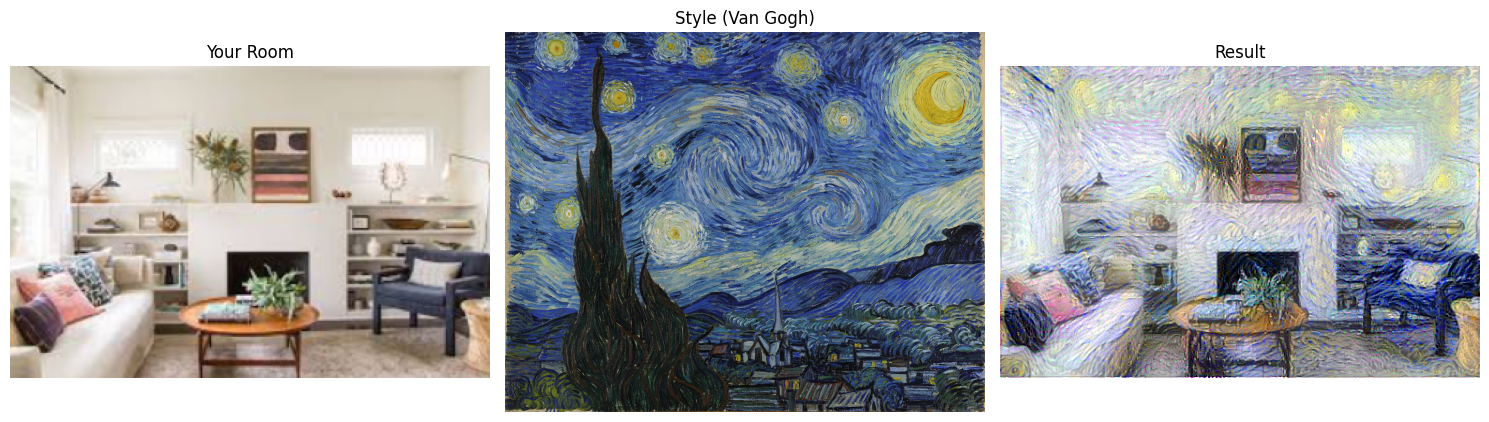

In [ ]:
result = style_transfer('your_room.png', 'styles/van_gogh.jpg', steps=1000)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(Image.open('your_room.png'))
axes[0].set_title('Your Room')
axes[0].axis('off')
axes[1].imshow(Image.open('styles/van_gogh.jpg'))
axes[1].set_title('Style (Van Gogh)')
axes[1].axis('off')
axes[2].imshow(result)
axes[2].set_title('Result')
axes[2].axis('off')
plt.tight_layout()
plt.show()